<a href="https://colab.research.google.com/github/MMujtabaX/Deep-Learning/blob/main/deep_learning_tabular_codealong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Deep Learning on Tabular Data
### Code-Along Session — Dense Neural Networks

---

**Dataset:** UCI Heart Disease Dataset (loaded via `ucimlrepo` package)  
**Task:** Binary Classification — Predict whether a patient has heart disease (1) or not (0)

**What we'll cover:**
1. Loading a real tabular dataset from UCI repository
2. Exploratory Data Analysis (EDA)
3. Preprocessing — scaling, encoding, train/test split
4. Building a Dense Neural Network
5. Training & monitoring
6. Evaluation — accuracy, confusion matrix, ROC curve
7. Inspecting predictions
8. Experiment zone — try different architectures

---
**Features in this dataset:**
| Feature | Description |
|---|---|
| age | Age in years |
| sex | 1=Male, 0=Female |
| cp | Chest pain type (0–3) |
| trestbps | Resting blood pressure |
| chol | Serum cholesterol (mg/dl) |
| fbs | Fasting blood sugar > 120 mg/dl |
| restecg | Resting ECG results |
| thalach | Max heart rate achieved |
| exang | Exercise-induced angina |
| oldpeak | ST depression induced by exercise |
| slope | Slope of peak exercise ST segment |
| ca | Number of major vessels colored by fluoroscopy |
| thal | Thal (3=normal, 6=fixed defect, 7=reversible) |

## 📦 Step 1: Install & Import Libraries

In [ ]:
# Install the UCI ML Repository package (not pre-installed in Colab)
!pip install ucimlrepo --quiet

print("✅ Installation complete!")

✅ Installation complete!


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# UCI dataset loader
from ucimlrepo import fetch_ucirepo

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("✅ TensorFlow version:", tf.__version__)
print("✅ All libraries loaded!")

✅ TensorFlow version: 2.19.0
✅ All libraries loaded!


## 📂 Step 2: Load the Dataset

We use the **UCI ML Repository** — a gold-standard source of real-world datasets.  
One line fetches the Heart Disease dataset directly.

In [ ]:
# Fetch the Heart Disease dataset (ID = 45) directly from UCI
heart_disease = fetch_ucirepo(id=45)

# Extract features and target
X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

print("✅ Dataset loaded successfully!")
print(f"\n📊 Features shape : {X.shape}")
print(f"📊 Target shape   : {y.shape}")
print(f"\n🔢 Feature columns: {list(X.columns)}")
print(f"🎯 Target column  : {list(y.columns)}")

✅ Dataset loaded successfully!

📊 Features shape : (303, 13)
📊 Target shape   : (303, 1)

🔢 Feature columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
🎯 Target column  : ['num']


In [ ]:
# The original target has values 0,1,2,3,4
# We convert to binary: 0 = no disease, 1 = disease
y = y.iloc[:, 0]          # Convert from DataFrame to Series
y = (y > 0).astype(int)   # Binary: 0 = healthy, 1 = has heart disease

# Combine for EDA
df = X.copy()
df['target'] = y.values

print("📋 First 5 rows:")
df.head()

📋 First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 🔍 Step 3: Exploratory Data Analysis (EDA)

**Always understand your data before building any model!**

In [ ]:
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Values:")
print(df.isnull().sum())

DATASET OVERVIEW
Rows    : 303
Columns : 14

Data Types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
target        int64
dtype: object

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [ ]:
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


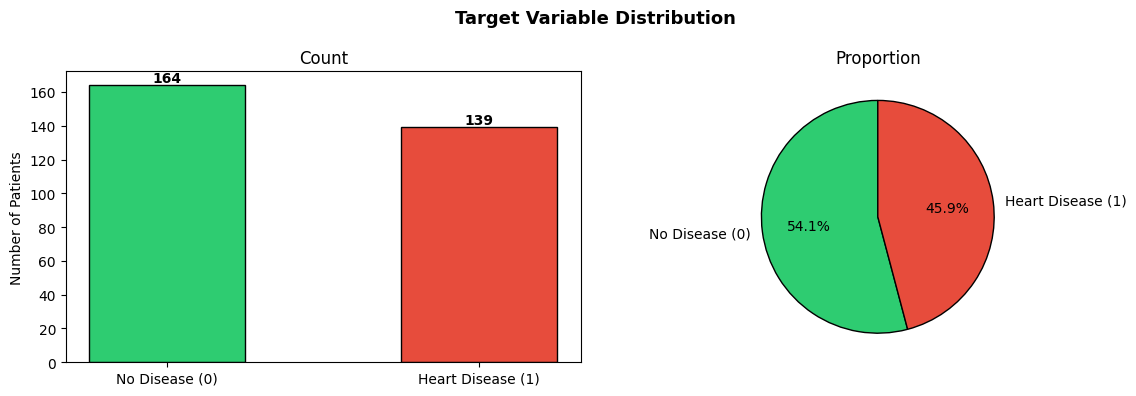

In [ ]:
# Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Variable Distribution', fontsize=13, fontweight='bold')

counts = df['target'].value_counts()
labels = ['No Disease (0)', 'Heart Disease (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Count')
axes[0].set_ylabel('Number of Patients')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Proportion')

plt.tight_layout()
plt.show()

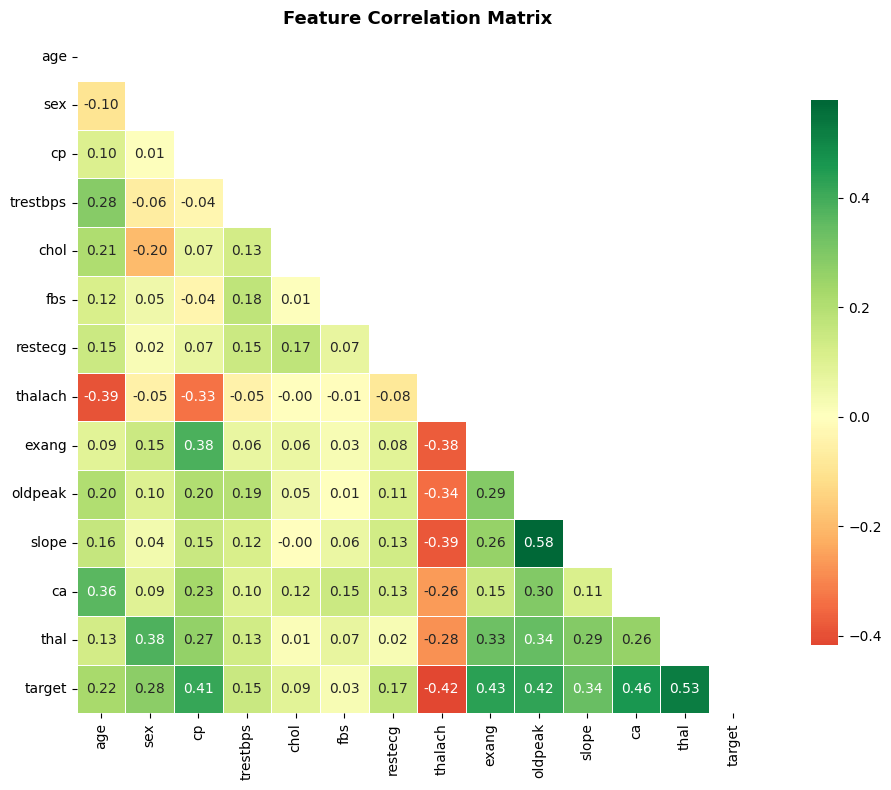


📌 Look at the bottom row — correlation of each feature with the TARGET
   Positive values = higher feature → more likely disease
   Negative values = higher feature → less likely disease


In [ ]:
# Correlation heatmap
plt.figure(figsize=(11, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Look at the bottom row — correlation of each feature with the TARGET")
print("   Positive values = higher feature → more likely disease")
print("   Negative values = higher feature → less likely disease")

## ⚙️ Step 4: Preprocessing

Three things to do before training:
1. **Handle missing values** — drop or impute
2. **Split** — training set vs test set
3. **Scale features** — StandardScaler brings all features to the same range

In [ ]:
# --- Step 4a: Handle missing values ---
print(f"Rows before dropping NaN: {df.shape[0]}")
df_clean = df.dropna()
print(f"Rows after  dropping NaN: {df_clean.shape[0]}")

X_clean = df_clean.drop('target', axis=1).values
y_clean = df_clean['target'].values

print(f"\nFinal X shape : {X_clean.shape}")
print(f"Final y shape : {y_clean.shape}")
print(f"Class balance : {np.bincount(y_clean)} (0s, 1s)")

Rows before dropping NaN: 303
Rows after  dropping NaN: 297

Final X shape : (297, 13)
Final y shape : (297,)
Class balance : [160 137] (0s, 1s)


In [ ]:
# --- Step 4b: Train / Test Split ---
# 80% training, 20% testing — stratify keeps class balance equal in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean   # Ensures equal % of disease cases in train & test
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Test set       : {X_test.shape[0]} samples")
print(f"Train classes  : {np.bincount(y_train)}")
print(f"Test  classes  : {np.bincount(y_test)}")

Training set   : 237 samples
Test set       : 60 samples
Train classes  : [128 109]
Test  classes  : [32 28]


In [ ]:
# --- Step 4c: Feature Scaling ---
# StandardScaler: transforms each feature to mean=0, std=1
# CRITICAL: fit ONLY on training data, then transform both sets
# (If we fit on test data too, we're 'leaking' test info into training — data leakage!)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # Transform only on test

print("Before scaling — mean of first feature:", X_train[:, 0].mean().round(2))
print("After  scaling — mean of first feature:", X_train_scaled[:, 0].mean().round(6))
print()
print("Before scaling — std of first feature:", X_train[:, 0].std().round(2))
print("After  scaling — std of first feature:", X_train_scaled[:, 0].std().round(6))
print("\n✅ All features are now on the same scale!")

Before scaling — mean of first feature: 54.77
After  scaling — mean of first feature: -0.0

Before scaling — std of first feature: 9.01
After  scaling — std of first feature: 1.0

✅ All features are now on the same scale!


## 🏗️ Step 5: Build the Neural Network

### Architecture
```
Input Layer:    13 neurons  (one per feature)
      ↓
Hidden Layer 1: 64 neurons  (ReLU)
      ↓
Hidden Layer 2: 32 neurons  (ReLU)
      ↓
Hidden Layer 3: 16 neurons  (ReLU)
      ↓
Output Layer:    1 neuron   (Sigmoid → probability of heart disease)
```

**Why Sigmoid at output?**  
We have a binary outcome (0 or 1). Sigmoid squishes any value to [0, 1] — perfect for outputting a probability.

In [ ]:
#from keras.model import Sequential
from keras.layers import Dense


model=keras.Sequential()

#1st hidden layer
model.layer(Dense(56,activation='relu',input_dim=13))

#2nd hidden layer
model.layer(Dense(40,activation='relu'))

#3rd layer layer
model.layer(Dense(200, activation='relu'))

#output layer
model.layer(Dense(1,activation='sigmoid')) #always this activation for binary classification

#for multiple classification
#model.layer(Dense(3, activation='softmax'))

AttributeError: 'Sequential' object has no attribute 'layer'

In [ ]:
n_features = X_train_scaled.shape[1]
print(f"Number of input features: {n_features}")

model = keras.Sequential([
    layers.Input(shape=(n_features,)),

    # Hidden Layer 1
    layers.Dense(64, activation='relu', name='hidden_1'),
    layers.BatchNormalization(name='bn_1'),    # Normalize activations within each batch
    layers.Dropout(0.3, name='dropout_1'),

    # Hidden Layer 2
    layers.Dense(32, activation='relu', name='hidden_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.Dropout(0.3, name='dropout_2'),

    # Hidden Layer 3
    layers.Dense(16, activation='relu', name='hidden_3'),

    # Output Layer — 1 neuron, sigmoid for binary probability
    layers.Dense(1, activation='sigmoid', name='output')
], name='HeartDisease_Classifier')

model.summary()

Number of input features: 13


Model: "HeartDisease_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 32)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,905 (15.25 KB)

 Trainable params: 3,713 (14.50 KB)

 Non-trainable params: 192 (768.00 B)

## ⚡ Step 6: Compile the Model

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',   # Binary task → binary crossentropy
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),           # Area Under ROC Curve
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)

print("✅ Model compiled!")
print("\n📌 Why binary_crossentropy?")
print("   → Output is a single probability (0 to 1)")
print("   → Use sparse_categorical_crossentropy for multi-class")
print("   → Use binary_crossentropy for yes/no prediction")

✅ Model compiled!

📌 Why binary_crossentropy?
   → Output is a single probability (0 to 1)
   → Use sparse_categorical_crossentropy for multi-class
   → Use binary_crossentropy for yes/no prediction


## 🚀 Step 7: Train the Model

We'll also use **Early Stopping** — automatically stop training when the model stops improving on the validation set.

In [ ]:
# Early stopping: stop if val_loss doesn't improve for 10 epochs
# restore_best_weights: rewind to the best epoch automatically
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)

print(f"\n🎉 Training complete! Stopped at epoch {len(history.history['loss'])}")

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.6153 - auc: 0.5408 - loss: 0.7898 - precision: 0.6417 - recall: 0.2254 - val_accuracy: 0.5556 - val_auc: 0.5206 - val_loss: 0.6838 - val_precision: 0.5926 - val_recall: 0.7619
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6446 - auc: 0.6976 - loss: 0.6419 - precision: 0.6756 - recall: 0.3044 - val_accuracy: 0.5278 - val_auc: 0.5587 - val_loss: 0.6756 - val_precision: 0.5833 - val_recall: 0.6667
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6486 - auc: 0.7732 - loss: 0.5734 - precision: 0.6744 - recall: 0.3415 - val_accuracy: 0.5556 - val_auc: 0.5841 - val_loss: 0.6690 - val_precision: 0.6087 - val_recall: 0.6667
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7380 - auc: 0.8097 - loss: 0.5321 - precision: 0.8092 - recall: 0.5063 - val_accuracy: 0.5833 - val_auc: 0.6143 - val_loss: 0.6606 - val_precision: 0.6500 - val_recall: 0.6190
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s

## 📈 Step 8: Visualize Training History

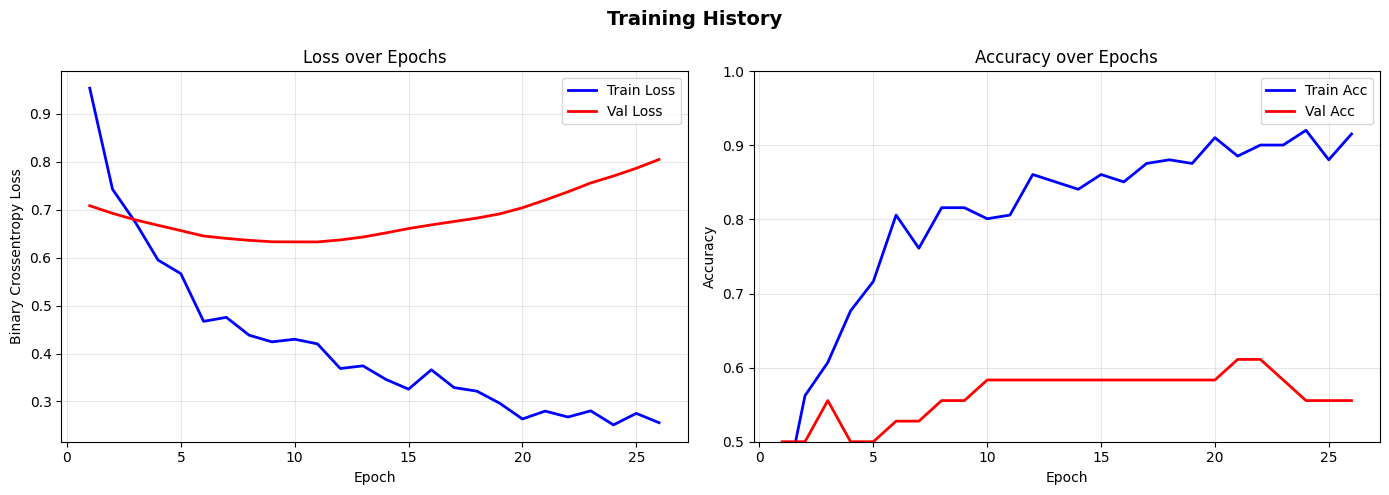

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training History', fontsize=14, fontweight='bold')
epochs_range = range(1, len(history.history['loss']) + 1)

# Loss
axes[0].plot(epochs_range, history.history['loss'],     'b-', label='Train Loss', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'], 'r-', label='Val Loss',   linewidth=2)
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Binary Crossentropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_range, history.history['accuracy'],     'b-', label='Train Acc', linewidth=2)
axes[1].plot(epochs_range, history.history['val_accuracy'], 'r-', label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim([0.5, 1.0])

plt.tight_layout()
plt.show()

## 🧪 Step 9: Evaluate on Test Set

In [ ]:
results = model.evaluate(X_test_scaled, y_test, verbose=0)
metric_names = model.metrics_names

print("=" * 45)
print("       TEST SET PERFORMANCE")
print("=" * 45)
for name, val in zip(metric_names, results):
    print(f"  {name:<12}: {val:.4f}")
print("=" * 45)

       TEST SET PERFORMANCE
  loss        : 0.4507
  compile_metrics: 0.8833


## 🔍 Step 10: Confusion Matrix

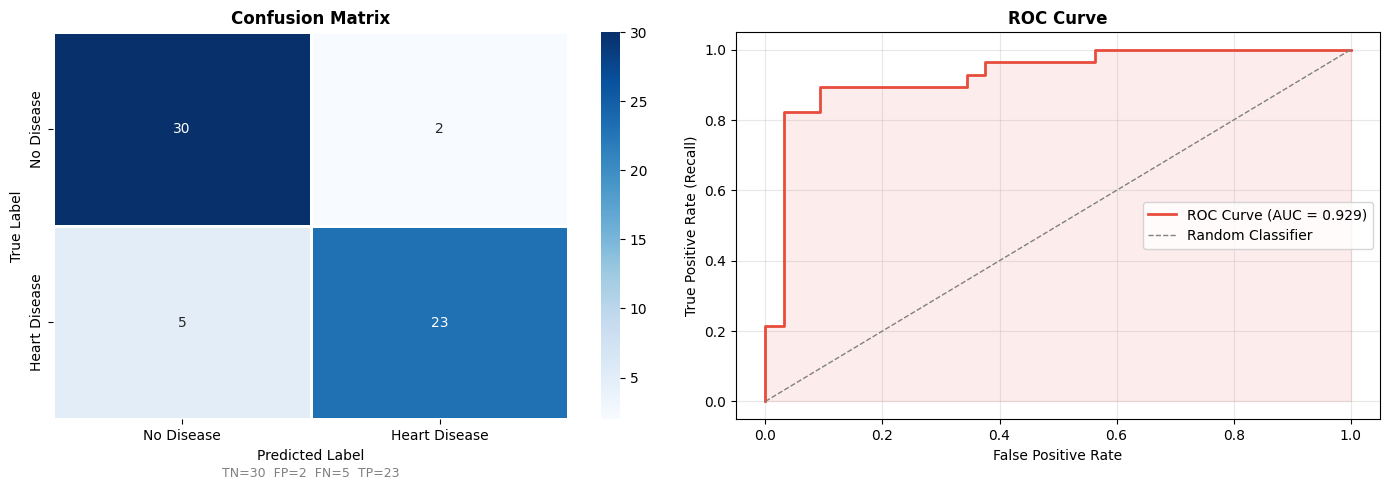


📌 Reading the Confusion Matrix:
  True Negatives  (TN) = 30 — Correctly predicted NO disease
  False Positives (FP) = 2 — Wrongly predicted disease (was healthy)
  False Negatives (FN) = 5 — Missed actual disease cases ← most dangerous!
  True Positives  (TP) = 23 — Correctly predicted disease


In [ ]:
# Get predictions
y_pred_prob = model.predict(X_test_scaled, verbose=0).flatten()  # Probabilities (0 to 1)
y_pred      = (y_pred_prob >= 0.5).astype(int)                   # Convert to 0 or 1

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Confusion Matrix Heatmap ---
labels_cm = ['No Disease', 'Heart Disease']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_cm, yticklabels=labels_cm,
            ax=axes[0], linewidths=1)
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=12)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Annotate quadrants
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.15, f'TN={tn}  FP={fp}  FN={fn}  TP={tp}',
            transform=axes[0].transAxes, ha='center', fontsize=9, color='gray')

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#e74c3c', lw=2,
             label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate (Recall)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Reading the Confusion Matrix:")
print(f"  True Negatives  (TN) = {tn} — Correctly predicted NO disease")
print(f"  False Positives (FP) = {fp} — Wrongly predicted disease (was healthy)")
print(f"  False Negatives (FN) = {fn} — Missed actual disease cases ← most dangerous!")
print(f"  True Positives  (TP) = {tp} — Correctly predicted disease")

In [ ]:
print("Detailed Classification Report:")
print("=" * 55)
print(classification_report(y_test, y_pred,
                             target_names=['No Disease', 'Heart Disease']))

Detailed Classification Report:
               precision    recall  f1-score   support

   No Disease       0.86      0.94      0.90        32
Heart Disease       0.92      0.82      0.87        28

     accuracy                           0.88        60
    macro avg       0.89      0.88      0.88        60
 weighted avg       0.89      0.88      0.88        60



## 🔮 Step 11: Inspect Individual Predictions

Let's see what the model outputs for real patients.

In [ ]:
feature_names = list(df_clean.drop('target', axis=1).columns)

print("Sample Predictions on Test Patients:")
print("=" * 70)
print(f"{'Patient':<10} {'True':<12} {'Predicted':<14} {'Confidence':<14} {'Status'}")
print("-" * 70)

for i in range(15):
    true     = y_test[i]
    pred     = y_pred[i]
    prob     = y_pred_prob[i]
    conf     = prob if pred == 1 else 1 - prob
    true_lbl = 'Disease' if true == 1 else 'No Disease'
    pred_lbl = 'Disease' if pred == 1 else 'No Disease'
    status   = '✅ Correct' if true == pred else '❌ Wrong'
    print(f"{i+1:<10} {true_lbl:<12} {pred_lbl:<14} {conf*100:<12.1f}% {status}")

Sample Predictions on Test Patients:
Patient    True         Predicted      Confidence     Status
----------------------------------------------------------------------
1          No Disease   No Disease     78.6        % ✅ Correct
2          No Disease   No Disease     74.8        % ✅ Correct
3          No Disease   No Disease     52.8        % ✅ Correct
4          No Disease   No Disease     63.8        % ✅ Correct
5          No Disease   No Disease     56.4        % ✅ Correct
6          No Disease   No Disease     72.8        % ✅ Correct
7          Disease      Disease        64.8        % ✅ Correct
8          No Disease   No Disease     68.6        % ✅ Correct
9          Disease      No Disease     56.1        % ❌ Wrong
10         No Disease   No Disease     66.2        % ✅ Correct
11         Disease      Disease        66.5        % ✅ Correct
12         No Disease   No Disease     68.7        % ✅ Correct
13         No Disease   No Disease     57.4        % ✅ Correct
14         Dis

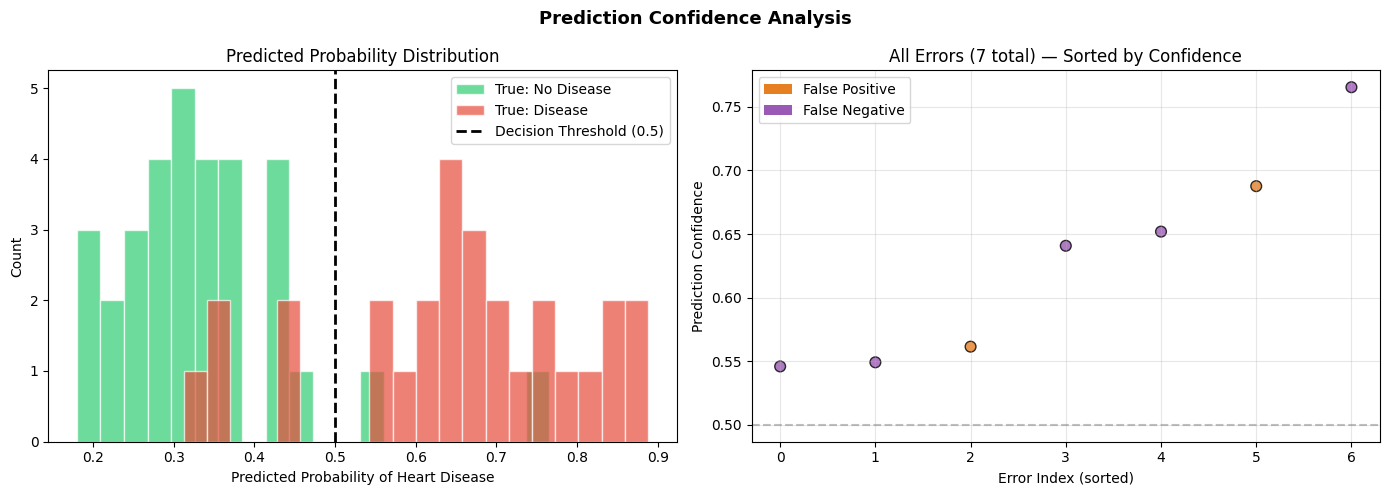

In [ ]:
# Visualize prediction confidence distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Prediction Confidence Analysis', fontsize=13, fontweight='bold')

# Histogram of predicted probabilities
axes[0].hist(y_pred_prob[y_test == 0], bins=20, alpha=0.7,
             color='#2ecc71', label='True: No Disease', edgecolor='white')
axes[0].hist(y_pred_prob[y_test == 1], bins=20, alpha=0.7,
             color='#e74c3c', label='True: Disease',    edgecolor='white')
axes[0].axvline(x=0.5, color='black', linestyle='--', lw=2, label='Decision Threshold (0.5)')
axes[0].set_title('Predicted Probability Distribution')
axes[0].set_xlabel('Predicted Probability of Heart Disease')
axes[0].set_ylabel('Count')
axes[0].legend()

# High confidence errors — what is the model most wrong about?
errors       = np.where(y_pred != y_test)[0]
error_confs  = np.abs(y_pred_prob[errors] - 0.5) + 0.5
error_types  = ['FP' if y_pred[e] == 1 else 'FN' for e in errors]
error_colors = ['#e67e22' if t == 'FP' else '#9b59b6' for t in error_types]

axes[1].scatter(range(len(errors)), np.sort(error_confs),
                c=error_colors, s=60, alpha=0.8, edgecolors='black')
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e67e22', label='False Positive'),
                   Patch(facecolor='#9b59b6', label='False Negative')]
axes[1].legend(handles=legend_elements)
axes[1].set_title(f'All Errors ({len(errors)} total) — Sorted by Confidence')
axes[1].set_xlabel('Error Index (sorted)')
axes[1].set_ylabel('Prediction Confidence')
axes[1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🎯 Step 12: Experiment Zone

### Your Turn! Modify and re-run to explore:

**Ideas:**
- Remove `BatchNormalization` layers — does accuracy drop?
- Set `DROPOUT_RATE = 0.0` and train longer — do you see overfitting?
- Change threshold from 0.5 to 0.3 — how does Recall change? (important for medical use!)
- Add a 4th hidden layer
- Try `activation='tanh'` instead of ReLU

In [ ]:
# ===================================================
# 🔧 EXPERIMENT ZONE — Change these parameters!
# ===================================================

LAYER_SIZES       = [64, 32, 16]   # Neurons per hidden layer — add/remove layers!
ACTIVATION        = 'relu'         # Try: 'tanh', 'sigmoid'
DROPOUT_RATE      = 0.3            # Try: 0.0 (off), 0.5 (aggressive)
LEARNING_RATE     = 0.001          # Try: 0.01 (faster but unstable), 0.0001 (slow but stable)
USE_BATCH_NORM    = True           # Try: False
DECISION_THRESHOLD = 0.5           # Try: 0.3 (catch more disease — higher recall)
MAX_EPOCHS        = 100

# ===================================================

tf.random.set_seed(42)

exp_layers = [layers.Input(shape=(n_features,))]
for i, size in enumerate(LAYER_SIZES):
    exp_layers.append(layers.Dense(size, activation=ACTIVATION, name=f'hidden_{i+1}'))
    if USE_BATCH_NORM:
        exp_layers.append(layers.BatchNormalization())
    exp_layers.append(layers.Dropout(DROPOUT_RATE))
exp_layers.append(layers.Dense(1, activation='sigmoid', name='output'))

exp_model = keras.Sequential(exp_layers, name='Experiment_Model')
exp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

exp_model.summary()

early_stop_exp = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True, verbose=0
)

exp_history = exp_model.fit(
    X_train_scaled, y_train,
    epochs=MAX_EPOCHS,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop_exp],
    verbose=0
)

# Evaluate
exp_pred_prob = exp_model.predict(X_test_scaled, verbose=0).flatten()
exp_pred      = (exp_pred_prob >= DECISION_THRESHOLD).astype(int)

from sklearn.metrics import accuracy_score, roc_auc_score

print("\n" + "=" * 50)
print("     EXPERIMENT RESULTS")
print("=" * 50)
print(f"  Architecture     : {LAYER_SIZES}")
print(f"  Activation       : {ACTIVATION}")
print(f"  Dropout Rate     : {DROPOUT_RATE}")
print(f"  Batch Norm       : {USE_BATCH_NORM}")
print(f"  Decision Thresh  : {DECISION_THRESHOLD}")
print(f"  Epochs Trained   : {len(exp_history.history['loss'])}")
print("-" * 50)
print(f"  Test Accuracy    : {accuracy_score(y_test, exp_pred)*100:.2f}%")
print(f"  ROC AUC Score    : {roc_auc_score(y_test, exp_pred_prob):.4f}")
print("=" * 50)
print(classification_report(y_test, exp_pred, target_names=['No Disease', 'Disease']))

Model: "Experiment_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,969 (15.50 KB)

 Trainable params: 3,745 (14.63 KB)

 Non-trainable params: 224 (896.00 B)


     EXPERIMENT RESULTS
  Architecture     : [64, 32, 16]
  Activation       : relu
  Dropout Rate     : 0.3
  Batch Norm       : True
  Decision Thresh  : 0.5
  Epochs Trained   : 26
--------------------------------------------------
  Test Accuracy    : 81.67%
  ROC AUC Score    : 0.9185
              precision    recall  f1-score   support

  No Disease       0.78      0.91      0.84        32
     Disease       0.87      0.71      0.78        28

    accuracy                           0.82        60
   macro avg       0.83      0.81      0.81        60
weighted avg       0.82      0.82      0.81        60



---
## 📚 Summary

| Concept | Applied To |
|---|---|
| **Tabular data loading** | `ucimlrepo` — UCI Heart Disease |
| **EDA** | Distributions, correlations, class balance |
| **Preprocessing** | `StandardScaler`, `train_test_split` |
| **Dense layers** | Fully connected, 13 → 64 → 32 → 16 → 1 |
| **BatchNormalization** | Stabilizes training, faster convergence |
| **Dropout** | Prevents overfitting |
| **Sigmoid output** | Binary classification probability |
| **Binary crossentropy** | Loss for yes/no problems |
| **Early Stopping** | Automatic training cutoff |
| **ROC / AUC** | Better than accuracy for imbalanced data |
| **Decision threshold** | Tune tradeoff between Precision and Recall |

### 🔑 Key Takeaways
- For tabular data, always scale features — neural networks are sensitive to feature magnitude
- Fit the scaler on training data only — never leak test data!
- For medical problems, Recall often matters more than raw accuracy (better to catch disease)
- BatchNormalization + Dropout together = more stable, generalizable models

### 🚀 What's Next?
- Try other UCI datasets (diabetes, wine quality, bank churn)
- Compare against traditional ML (Random Forest, XGBoost)
- Explore hyperparameter tuning with `keras_tuner`